# [VQ-VAE](https://arxiv.org/abs/1711.00937)

## Introduction

Variational Auto Encoders (VAEs) can be thought of as what all but the last layer of a neural network is doing, namely feature extraction or seperating out the data. Thus given some data we can think of using a neural network for representation generation. 

Recall that the goal of a generative model is to estimate the probability distribution of high dimensional data such as images, videos, audio or even text by learning the underlying structure in the data as well as the dependencies between the different elements of the data. This is very useful since we can then use this representation to generate new data with similar properties. This way we can also learn useful features from the data in an unsupervised fashion.

The VQ-VAE uses a discrete latent representation mostly because many important real-world objects are discrete. For example in images we might have categories like "Cat", "Car", etc. and it might not make sense to interpolate between these categories. Discrete representations are also easier to model since each category has a single value whereas if we had a continous latent space then we will need to normalize this density function and learn the dependencies between the different variables which could be very complex.

We start by defining a latent embedding space of dimension `[K, D]` where `K` are the number of embeddings and `D` is the dimensionality of each latent embeddng vector, i.e. $e_i \in \mathbb{R}^{D}$. The model is comprised of an encoder and a decoder. The encoder will map the input to a sequence of discrete latent variables, whereas the decoder will try to reconstruct the input from these latent sequences. 

More preciesly, the model will take in batches of RGB images,  say $x$, each of size 32x32 for our example, and pass it through a ConvNet encoder producing some output $E(x)$, where we make sure the channels are the same as the dimensionality of the latent embedding vectors. To calculate the discrete latent variable we find the nearest embedding vector and output it's index. 

The input to the decoder is the embedding vector corresponding to the index which is passed through the decoder to produce the reconstructed image. 

Since the nearest neighbour lookup has no real gradient in the backward pass we simply pass the gradients from the decoder to the encoder  unaltered. The intuition is that since the output representation of the encoder and the input to the decoder share the same `D` channel dimensional space, the gradients contain useful information for how the encoder has to change its output to lower the reconstruction loss.

## Loss

The total loss is actually composed of three components

1. **reconstruction loss**: which optimizes the decoder and encoder
1. **codebook loss**: due to the fact that gradients bypass the embedding, we use a dictionary learning algorithm  which uses an $l_2$  error to move the embedding vectors $e_i$ towards the encoder output
1. **commitment loss**:  since the volume of the embedding space is dimensionless, it can grow arbirtarily if the embeddings $e_i$ do not train as fast as  the encoder parameters, and thus we add a commitment loss to make sure that the encoder commits to an embedding

In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3080 Ti


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torch.optim as optim

import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torchvision.utils import make_grid
from torchmetrics.image.fid import FrechetInceptionDistance

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Load Data

In [4]:
training_data = datasets.CIFAR10(root="../data/cifar10", train=True, download=True,
                                  transform=transforms.Compose([
                                      transforms.ToTensor(),
                                      transforms.Normalize((0.5,0.5,0.5), (1.0,1.0,1.0))
                                  ]))

test_data = datasets.CIFAR10(root="../data/cifar10", train=False, download=True,
                                  transform=transforms.Compose([
                                      transforms.ToTensor(),
                                      transforms.Normalize((0.5,0.5,0.5), (1.0,1.0,1.0))
                                  ]))

In [5]:
data_variance = np.var(training_data.data / 255.0)

In [6]:
data_variance

np.float64(0.06328692405746422)

## Vector Quantizer Layer

This layer takes a tensor to be quantized. The channel dimension will be used as the space in which to quantize. All other dimensions will be flattened and will be seen as different examples to quantize.

The output tensor will have the same shape as the input.

As an example for a `BCHW` tensor of shape `[16, 64, 32, 32]`, we will first convert it to an `BHWC` tensor of shape `[16, 32, 32, 64]` and then reshape it into `[16384, 64]` and all `16384` vectors of size `64`  will be quantized independently. In otherwords, the channels are used as the space in which to quantize. All other dimensions will be flattened and be seen as different examples to quantize, `16384` in this case.

In [7]:
from model import VectorQuantizer

We will also implement a slightly modified version  which will use exponential moving averages to update the embedding vectors instead of an auxillary loss. This has the advantage that the embedding updates are independent of the choice of optimizer for the encoder, decoder and other parts of the architecture. For most experiments the EMA version trains faster than the non-EMA version.

In [8]:
from model import VectorQuantizerEMA

## Encoder & Decoder Architecture

The encoder and decoder architecture is based on a ResNet

In [9]:
from model import Residual, ResidualStack, Encoder, Decoder

## Train

In [10]:
batch_size = 256
num_training_updates = 15000

num_hiddens = 128
num_residual_hiddens = 32
num_residual_layers = 2

embedding_dim = 64
num_embeddings = 512

commitment_cost = 0.25

decay = 0.99

learning_rate = 1e-3

In [11]:
training_loader = DataLoader(training_data, 
                             batch_size=batch_size, 
                             shuffle=True,
                             pin_memory=True)

In [12]:
test_loader = DataLoader(test_data,
                         batch_size=32,
                         shuffle=True,
                         pin_memory=True)

In [13]:
from model import Model

In [14]:
model = Model(num_hiddens, num_residual_layers, num_residual_hiddens,
              num_embeddings, embedding_dim, 
              commitment_cost, decay).to(device)

In [17]:
optimizer = optim.Adam(model.parameters(), lr=learning_rate, amsgrad=False)

In [18]:
model.train()
train_res_recon_error = []
train_res_perplexity = []

for i in range(num_training_updates):
    (data, _) = next(iter(training_loader))
    data = data.to(device)
    optimizer.zero_grad()

    vq_loss, data_recon, perplexity = model(data)
    recon_error = F.mse_loss(data_recon, data) / data_variance
    loss = recon_error + vq_loss
    loss.backward()

    optimizer.step()
    
    train_res_recon_error.append(recon_error.item())
    train_res_perplexity.append(perplexity.item())

    if (i+1) % 100 == 0:
        print('%d iterations' % (i+1))
        print('recon_error: %.3f' % np.mean(train_res_recon_error[-100:]))
        print('perplexity: %.3f' % np.mean(train_res_perplexity[-100:]))
        print()

100 iterations
recon_error: 1.004
perplexity: 1.000

200 iterations
recon_error: 0.983
perplexity: 1.000

300 iterations
recon_error: 0.979
perplexity: 1.000

400 iterations
recon_error: 0.983
perplexity: 1.000

500 iterations
recon_error: 0.980
perplexity: 1.000

600 iterations
recon_error: 0.532
perplexity: 2.402

700 iterations
recon_error: 0.329
perplexity: 3.057

800 iterations
recon_error: 0.234
perplexity: 7.556

900 iterations
recon_error: 0.181
perplexity: 15.247

1000 iterations
recon_error: 0.159
perplexity: 27.440

1100 iterations
recon_error: 0.146
perplexity: 38.156

1200 iterations
recon_error: 0.135
perplexity: 48.102

1300 iterations
recon_error: 0.121
perplexity: 57.367

1400 iterations
recon_error: 0.114
perplexity: 63.338

1500 iterations
recon_error: 0.109
perplexity: 69.128

1600 iterations
recon_error: 0.105
perplexity: 74.494

1700 iterations
recon_error: 0.102
perplexity: 79.748

1800 iterations
recon_error: 0.101
perplexity: 84.356

1900 iterations
recon_error

In [ ]:
torch.save(model.state_dict(), "vqvae_cifar10.pth")

## Plot Loss

In [38]:
train_res_recon_error_smooth = savgol_filter(train_res_recon_error, 201, 7)
train_res_perplexity_smooth = savgol_filter(train_res_perplexity, 201, 7)

Text(0.5, 0, 'iteration')

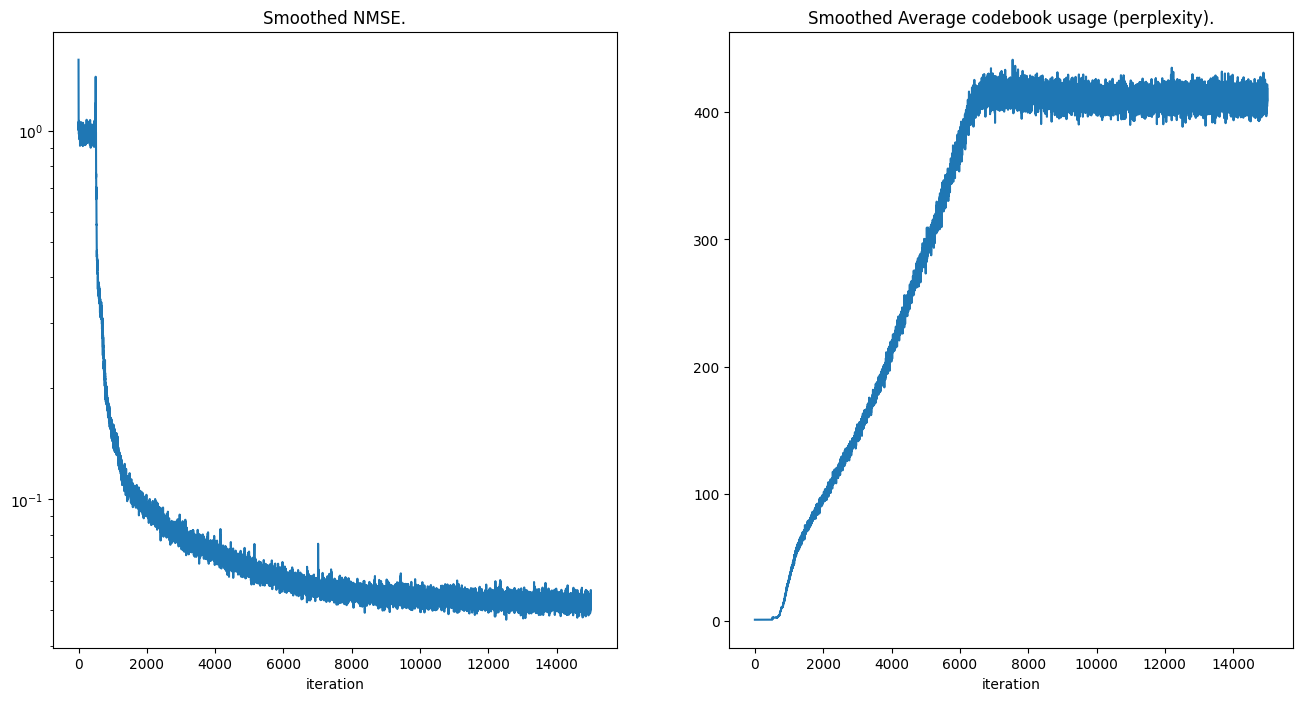

In [40]:
f = plt.figure(figsize=(16,8))
ax = f.add_subplot(1,2,1)
ax.plot(train_res_recon_error)
ax.set_yscale('log')
ax.set_title('Smoothed NMSE.')
ax.set_xlabel('iteration')

ax = f.add_subplot(1,2,2)
ax.plot(train_res_perplexity)
ax.set_title('Smoothed Average codebook usage (perplexity).')
ax.set_xlabel('iteration')

## View Reconstructions

In [ ]:
model.eval()

(valid_originals, _) = next(iter(test_loader))
valid_originals = valid_originals.to(device)

vq_output_eval = model._pre_vq_conv(model._encoder(valid_originals))
_, valid_quantize, _, _ = model._vq_vae(vq_output_eval)
valid_reconstructions = model._decoder(valid_quantize)

In [50]:
(train_originals, _) = next(iter(training_loader))
train_originals = train_originals.to(device)
_, train_reconstructions, _, _ = model._vq_vae(train_originals)

In [ ]:
def show(img):
    npimg = img.numpy()
    
    fig = plt.imshow(np.transpose(npimg, (1,2,0)), interpolation='nearest')
    fig.axes.get_xaxis().set_visible(False)
    fig.axes.get_yaxis().set_visible(False)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0510363..1.088984].


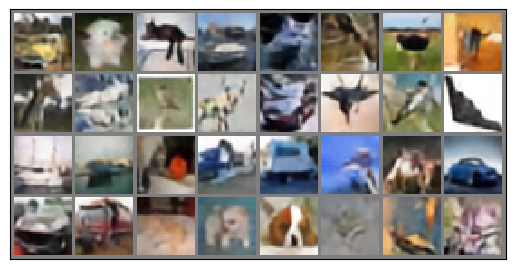

In [52]:
show(make_grid(valid_reconstructions.cpu().data)+0.5, )

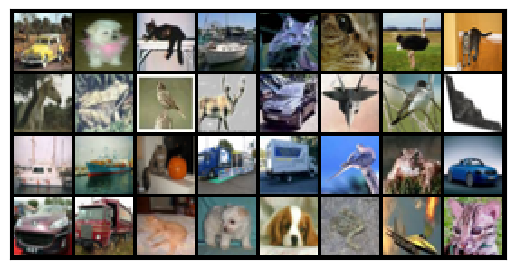

In [53]:
show(make_grid(valid_originals.cpu()+0.5))

## FID

In [15]:
model.load_state_dict(torch.load('vqvae_cifar10.pth', map_location=device))

<All keys matched successfully>

In [20]:
from torchvision.transforms import Resize
from tqdm import tqdm

@torch.no_grad()
def compute_tokenizer_fid(model, test_loader, device):
    model.eval()
    fid = FrechetInceptionDistance(feature=2048).to(device)
    resize = Resize((299, 299))

    for x, _ in tqdm(test_loader, desc="Computing FID"):
        x = x.to(device)  # [-0.5, 0.5]

        # [-1, 1]
        _, recon, _ = model(x)

        # real -> map to [0,1]
        real01 = (x + 0.5).clamp(0, 1)

        # fake -> map to [0,1]
        fake01 = ((recon + 1.0) * 0.5).clamp(0, 1)

        # Resize for Inception
        real01 = resize(real01)
        fake01 = resize(fake01)

        # Convert to uint8 [0,255]
        real_u8 = (real01 * 255.0).round().to(torch.uint8)
        fake_u8 = (fake01 * 255.0).round().to(torch.uint8)

        fid.update(real_u8, real=True)
        fid.update(fake_u8, real=False)

    return float(fid.compute())

In [21]:
fid = compute_tokenizer_fid(
    model=model,          #VQ-VAE
    test_loader=test_loader,
    device=device
)
print(f"VQ-VAE FID on CIFAR-10: {fid:.2f}")

Computing FID: 100%|██████████| 313/313 [01:14<00:00,  4.21it/s]


VQ-VAE FID on CIFAR-10: 64.39


In [23]:
def compute_final_nmse(model, test_loader, device):
    model.eval()
    
    total_num = 0.0
    total_den = 0.0
    
    with torch.no_grad():
        for images, _ in tqdm(test_loader, desc="Computing NMSE"):
            images = images.to(device)
            
            _, recon, _ = model(images)
            
            # recon is in [-1,1], images likely in [-1,1]
            num = torch.sum((images - recon) ** 2)
            den = torch.sum(images ** 2)
            
            total_num += num.item()
            total_den += den.item()
    
    nmse = total_num / total_den
    return nmse

In [24]:
nmse = compute_final_nmse(model, test_loader, device)
print(f"VQ-VAE NMSE on CIFAR-10: {nmse:.2f}")

Computing NMSE: 100%|██████████| 313/313 [00:03<00:00, 94.63it/s] 

VQ-VAE NMSE on CIFAR-10: 0.05


In [25]:
def compute_final_perplexity(model, test_loader, device):
    model.eval()
    
    total_perplexity = 0.0
    num_batches = 0
    
    with torch.no_grad():
        for images, _ in tqdm(test_loader, desc="Computing Perplexity"):
            images = images.to(device)
            
            z = model._encoder(images)
            z = model._pre_vq_conv(z)
            _, _, perplexity, _ = model._vq_vae(z)
            
            total_perplexity += perplexity.item()
            num_batches += 1
    
    return total_perplexity / num_batches

In [26]:
perplexity = compute_final_perplexity(model, test_loader, device)
print(f"VQ-VAE Perplexity on CIFAR-10: {perplexity:.2f}")

Computing Perplexity: 100%|██████████| 313/313 [00:02<00:00, 108.18it/s]

VQ-VAE Perplexity on CIFAR-10: 333.54
